In [1]:
%cd ..

/Users/antodima/Code/aptax


In [2]:
import tiktoken
from tqdm import tqdm
from pathlib import Path

import jax
import jax.numpy as jnp
import flax.nnx as nnx
import optax

import orbax
from orbax import checkpoint
from jax.sharding import SingleDeviceSharding 

import numpy as np
import matplotlib.pyplot as plt

from aptax.llm import MiniGPT
from aptax.dataset import create_dataloader, StoryDataset

In [3]:
tokenizer = tiktoken.get_encoding("gpt2")
vocab_size = tokenizer.n_vocab

max_seq_len = 256
embed_dim = 216
num_heads = 6
ff_dim = 512
batch_size = 64

dataset = StoryDataset(max_seq_len, tokenizer)
dataloader, batches_per_epoch = create_dataloader(dataset, batch_size=batch_size, num_epochs=1)
print(f"Batches per epoch: {batches_per_epoch}")

model = MiniGPT(
    max_seq_len=max_seq_len,
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    num_heads=num_heads,
    ff_dim=ff_dim,
    num_transformer_blocks=3,
    rngs=nnx.Rngs(0),
)
print(model)

Loading stories from aptax/data/TinyStories-1000.txt...
Loaded 1,000 stories
Batches per epoch: 15


W0310 19:12:26.341706  671117 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


MiniGPT( # Param: 22,328,784 (89.3 MB)
  max_seq_len=256,
  embedding=TokenAndPositionEmbedding( # Param: 10,910,808 (43.6 MB)
    token_emb=Embed( # Param: 10,855,512 (43.4 MB)
      embedding=Param( # 10,855,512 (43.4 MB)
        value=Array(shape=(50257, 216), dtype=dtype('float32'))
      ),
      num_embeddings=50257,
      features=216,
      dtype=dtype('float32'),
      param_dtype=float32,
      promote_dtype=<function promote_dtype at 0x11480a020>
    ),
    pos_emb=Embed( # Param: 55,296 (221.2 KB)
      embedding=Param( # 55,296 (221.2 KB)
        value=Array(shape=(256, 216), dtype=dtype('float32'))
      ),
      num_embeddings=256,
      features=216,
      dtype=dtype('float32'),
      param_dtype=float32,
      promote_dtype=<function promote_dtype at 0x11480a020>
    )
  ),
  transformer_blocks=[TransformerBlock( # Param: 187,488 (750.0 KB)
    attn=MultiHeadAttention( # Param: 187,488 (750.0 KB)
      input_dim=216,
      embed_dim=216,
      num_heads=6,
      head_

In [4]:
num_epochs = 200
total_steps = num_epochs * batches_per_epoch
warmup_steps = max(1, total_steps // 10)
print(f"Total training steps: {total_steps:,}")
print(f"Warmup steps: {warmup_steps:,}")
lr_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=5e-3,
    warmup_steps=warmup_steps,
    decay_steps=total_steps,
    end_value=5e-5,
)
optimizer = nnx.ModelAndOptimizer(
    model,
    optax.adamw(learning_rate=lr_schedule, weight_decay=0.01),
)
metrics = nnx.MultiMetric(
    loss=nnx.metrics.Average('loss'),
)

Total training steps: 3,000
Warmup steps: 300


In [5]:
def loss_fn(model, batch):
    inputs, targets = batch
    logits = model(inputs)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits, targets
    ).mean()
    return loss, logits
    

@nnx.jit
def train_step(model, optimizer, metrics, batch):
    grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)
    (loss, logits), grads = grad_fn(model, batch)

    metrics.update(loss=loss, logits=logits, labels=batch[1])
    optimizer.update(grads)

In [6]:
prep_target_batch = jax.vmap(
    lambda tokens: jnp.concatenate((tokens[1:], jnp.array([0]))))

step = 0
epochs_losses = []
for epoch in range(num_epochs):
    epoch_losses = []
    for batch in (pbar:=tqdm(dataloader, total=batches_per_epoch)):
        inputs = jnp.array(batch).T
        targets = prep_target_batch(inputs)
        train_step(model, optimizer, metrics, (inputs, targets))

        for metric, value in metrics.compute().items():
            epoch_losses.append(value)
        metrics.reset()

        current_lr = lr_schedule(step)
        pbar.set_description(
            f"epoch: {epoch+1}/{num_epochs}, loss: {np.mean(epoch_losses):.4f}, lr: {current_lr:.2e}")
        step += 1
        
    epochs_losses.append(epoch_losses)

epoch: 200/200, loss: 0.0014, lr: 5.00e-05: 100%|██████████| 15/15 [01:00<00:00,  4.06s/it]


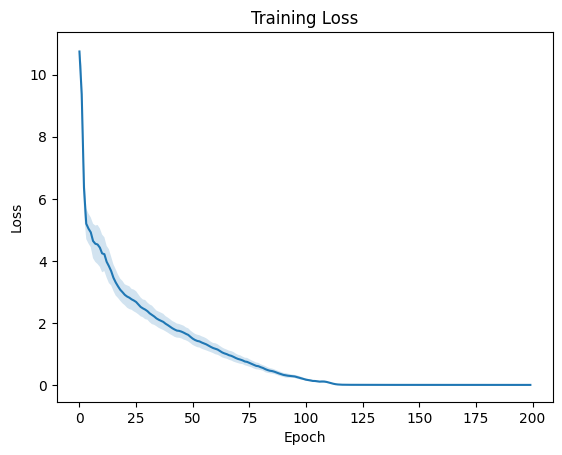

In [7]:
loss_means = np.array(epochs_losses).mean(axis=1)
x = np.arange(0, num_epochs)
loss_stds = np.array(epochs_losses).std(axis=1)
plt.plot(loss_means)
plt.fill_between(
    x, 
    np.subtract(loss_means, loss_stds), 
    np.add(loss_means, loss_stds), 
    alpha=0.2, 
    linestyle='-',
)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [8]:
checkpoint_path = Path.cwd() / "checkpoints" / "minigpt.orbax"
checkpointer = orbax.checkpoint.PyTreeCheckpointer()
checkpointer.save(checkpoint_path, nnx.state(model), force=True)
print(f"Model saved as {checkpoint_path}")

Model saved as /Users/antodima/Code/aptax/checkpoints/minigpt.orbax


In [9]:
checkpoint_path = Path.cwd() / "checkpoints" / "minigpt.orbax"
checkpointer = orbax.checkpoint.PyTreeCheckpointer()

cpu_device = jax.devices('cpu')[0]
cpu_sharding = SingleDeviceSharding(cpu_device)
restore_args = jax.tree_util.tree_map(
    lambda _: checkpoint.ArrayRestoreArgs(sharding=cpu_sharding),
    nnx.state(model)
)
nnx.state(model)
restored_state = checkpointer.restore(
    checkpoint_path,
    item=nnx.state(model),
    restore_args=restore_args)

nnx.update(model, restored_state)

In [ ]:
def generate_text(model, start_tokens, max_new_tokens=50, temperature=1.0):
    tokens = list(start_tokens)
    for _ in range(max_new_tokens):
        context = tokens[-model.max_seq_len:]
        print(context)
        # RIGHT-pad to match training (not left-pad!)
        actual_len = len(context)
        if actual_len < model.max_seq_len:
            context = context + [0] * (model.max_seq_len - actual_len)

        context_array = jnp.atleast_2d(jnp.array(context))
        logits = model(context_array)
        next_token_logits = logits[0, actual_len - 1, :] / temperature
        next_token = int(jnp.argmax(next_token_logits))
        if next_token == tokenizer.encode('<|endoftext|>', allowed_special={'<|endoftext|>'})[0]:
            break
        tokens.append(next_token)
    return tokenizer.decode(tokens)

def generate_story(model, story_prompt, temperature, max_new_tokens):
    start_tokens = tokenizer.encode(story_prompt)[:max_seq_len]
    generated = generate_text(model, start_tokens, max_new_tokens=max_new_tokens, temperature=temperature)
    return generated

def create_story(story_prompt, temperature, max_new_tokens):
    return generate_story(model, story_prompt, temperature, max_new_tokens)

create_story("Once upon a time ", 1.0, 25)